**Steps to perform hierarchical clustering:**
- Given n sample data points, view each point as an individual cluster with just that one point as a member (the centroid)
- Claculate the pairwise Euclidean distance between the centroids of all the clusters in your data (Here, minimum distance between clusters, maximum distance between clusters, average distance between clusters, or distance between two centroids can be consifered. In this example, we are considering the distance between 2 cluster centroids)
- Group the closest clusters/points together
- Repeat step 2 and step 3 until you get a single cluster containing all the data 
- Plot a dendrogram to show how the data has come together in a hierarchical structure. (A dendrogram is simply a diagram used to represent a tree structure, showing an arrangement of clusters from top to bottom)
- Decide the level to create clusters at. 

In [6]:
import numpy as np
from scipy.spatial.distance import pdist, cdist, squareform

In [2]:
# given a list of four sample data pointss, view each point as  a centroid that is also its own cluster with the point indices from 0 to 3:
samples = [ (1,7) ], [ (-5,9) ], [ (-9,4) ] , [ (4, -2) ]
samples = np.array(samples)

In [5]:
samples = samples.squeeze()

compute the pairwise euclidean distance between the centroids of all clusters......(remember initially each point is viewed as the centroid of its own cluster...)

In [8]:
samples

array([[ 1,  7],
       [-5,  9],
       [-9,  4],
       [ 4, -2]])

the pairwise distances between samples:

In [7]:
squareform(pdist(samples))

array([[ 0.        ,  6.32455532, 10.44030651,  9.48683298],
       [ 6.32455532,  0.        ,  6.40312424, 14.2126704 ],
       [10.44030651,  6.40312424,  0.        , 14.31782106],
       [ 9.48683298, 14.2126704 , 14.31782106,  0.        ]])

from the pairwise distances between the points computed above, group the closest point pairs together....
- in this case (1,7) and (-5,9) join intop a single cluster since they are the closest...with the remaining 2 points left as single member clusters
- the resultant three clusters are: [(1,7), (-5,9)] and [-9,4] and [4,-2]

calculate the mean point between the pointsof the two member cluster to find the new centroid:

In [10]:
np.mean([[1,7],[-5,9]], axis=0)

array([-2.,  8.])

add the centroid to the two single member centroids and then recalculate the distances:

In [11]:
new_centroids = [[-2, 8], [-9, 4], [4, -2]]

once again, we'll calculate the euclidean distance between the points and the centroid...

In [12]:
new_centroids = np.array(new_centroids)

In [13]:
squareform(pdist(new_centroids))

array([[ 0.        ,  8.06225775, 11.66190379],
       [ 8.06225775,  0.        , 14.31782106],
       [11.66190379, 14.31782106,  0.        ]])

from the new pairwise distances shown above, the smallest distance is 8.06...corresponding to the distance between the centroid (-2,8) and the point (-9,4)... the cluster now changes to...[(1,7), (-5,9), (-9,4)]

plot a dendrogram:
- <img src="../../resource_images/Screenshot 2026-04-26 at 10.57.27.png"/>

**Building a Hierarchy:**

In [14]:
# generate some dummy data as follows:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [15]:
# generate a rabdom cluster dataset to experiment with...
X, y = make_blobs(n_samples=1000, centers=8, n_features=2, random_state=800)

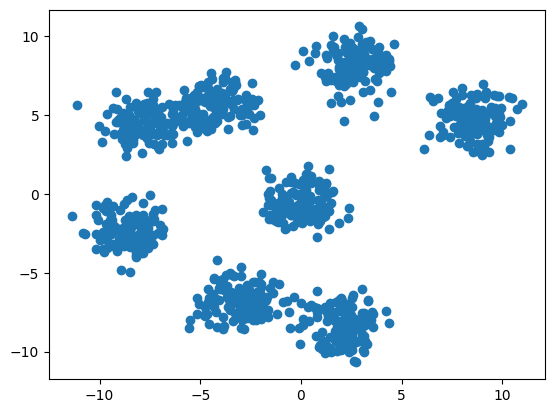

In [16]:
# visualise the data
plt.scatter(X[:, 0], X[:, 1])
plt.show()

from the toy example above...its clear that there's 8 clusters in there....
- we can easily generate the distance matrix using the built-in scipy packagelinkage

In [17]:
distances = linkage(X, method="centroid", metric="euclidean")
print(distances)

[[5.72000000e+02 7.62000000e+02 7.69412624e-03 2.00000000e+00]
 [3.00000000e+01 1.96000000e+02 8.87881891e-03 2.00000000e+00]
 [5.91000000e+02 8.70000000e+02 1.07476240e-02 2.00000000e+00]
 ...
 [1.98900000e+03 1.99200000e+03 7.81168528e+00 3.75000000e+02]
 [1.99500000e+03 1.99600000e+03 1.02408477e+01 7.50000000e+02]
 [1.99400000e+03 1.99700000e+03 1.20025814e+01 1.00000000e+03]]


In [18]:
distances.shape

(999, 4)

after we determine the linkage matrix, we can easily pass it through the dendrogram function provided by scipy.
- as the name suggests, the dendrogram function uses the computed distances to generate a visually clean way of parsing grouped information

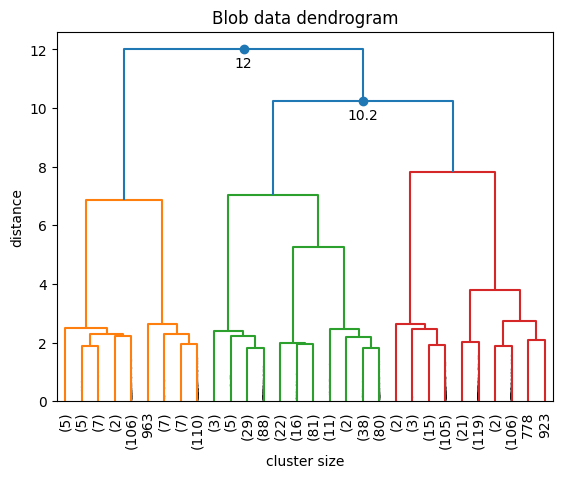

In [22]:
def annotated_dendrogram(*args, **kwargs):
    # standard dendrogram from scipy
    scipy_dendro = dendrogram(*args, truncate_mode='lastp', show_contracted=True, leaf_rotation=90)
    plt.title('Blob data dendrogram')
    plt.xlabel('cluster size')
    plt.ylabel('distance')
    for i, d, c in zip(scipy_dendro['icoord'], \
    scipy_dendro['dcoord'], \
    scipy_dendro['color_list']):
        x = 0.5 * sum(i[1:3])
        y = d[1]
        if y > 10:
            plt.plot(x, y, 'o', c=c)
            plt.annotate("%.3g" % y, (x, y), xytext=(0, -5), \
            textcoords='offset points', \
            va='top', ha='center')
    return scipy_dendro
dn = annotated_dendrogram(distances)
plt.show()

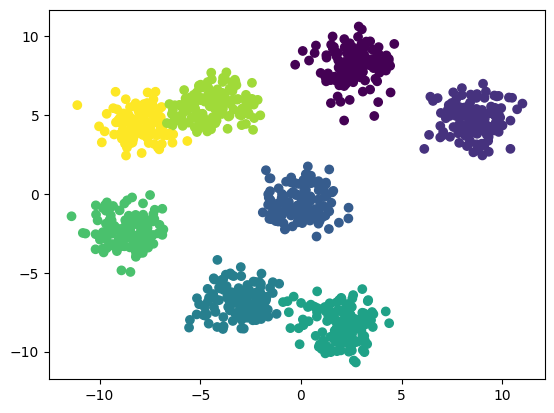

In [23]:
scipy_clusters = fcluster(distances, 3, criterion="distance")

plt.scatter(X[:,0], X[:,1], c=scipy_clusters)
plt.show()

the fcluster function uses the distances and information from the dendrogram to cluster the data into a number of groups based on a stated threshold. the number 3 represents the maximum inter-cluster distance

Applying linkage criteria:

In [24]:
methods = ['centroid','single','complete','average','weighted']

In [26]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist

centroid, c: 0.8125032571252165


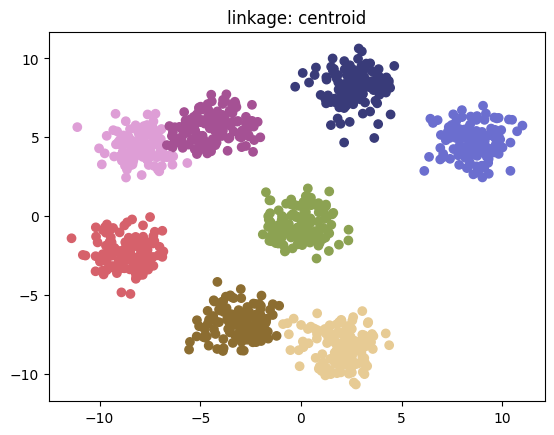

single, c: 0.7308099556411125


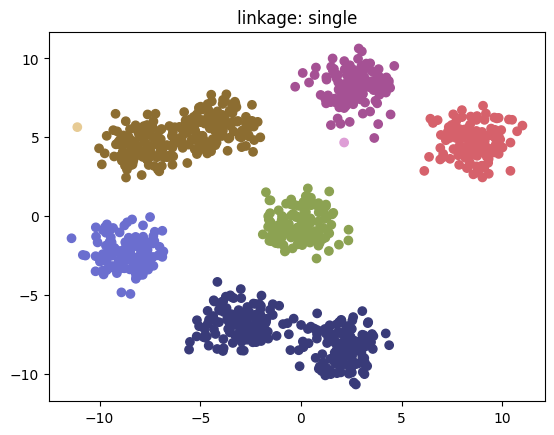

complete, c: 0.8066278244736527


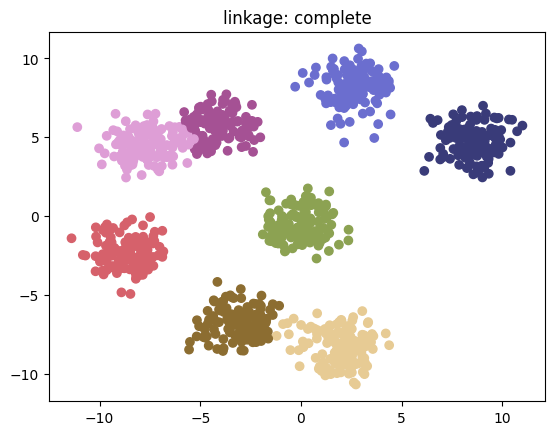

average, c: 0.8142237084667415


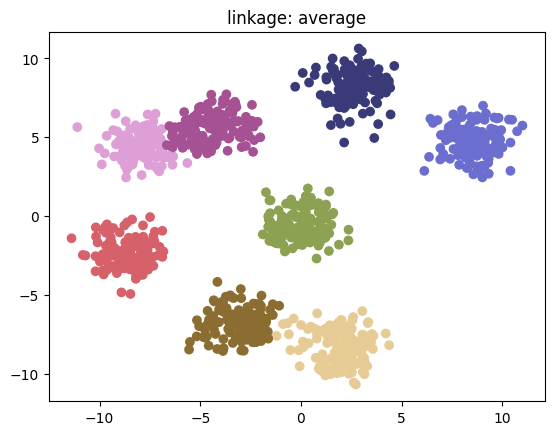

weighted, c: 0.8053720240216431


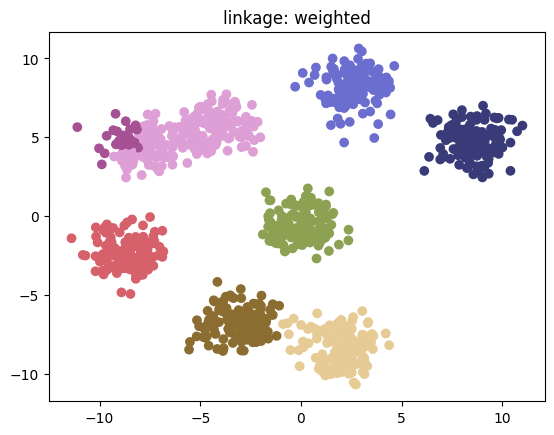

In [28]:
for method in methods:
    distances = linkage(X, method=method, metric="euclidean")
    c, coph_dists = cophenet(distances, pdist(X))
    clusters = fcluster(distances, 8, criterion="maxclust")
    print(f'{method}, c: {c}')
    plt.title('linkage: ' + method)
    plt.scatter(X[:,0], X[:,1], c=clusters, cmap='tab20b')
    plt.show()


as seen in the preceeding plots, by simply changing the linkage criteria, you can dramatically change the efficacy of clustering....computed with each change is the cophenet correlation coefficient which shows the best methods

**Agglomerative vs Divisive Clustering:**

In [29]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [33]:
ac = AgglomerativeClustering(n_clusters=8, metric="euclidean", linkage="average") # average linkage had the highest(best) cophenet correlation coefficient for this problem with 8 clusters
X, y = make_blobs(n_samples=1000, centers=8, n_features=2, random_state=800)

In [34]:
distances = linkage(X, method="average", metric="euclidean")
sklearn_clusters = ac.fit_predict(X)
scipy_clusters = fcluster(distances, 8, criterion = "maxclust")

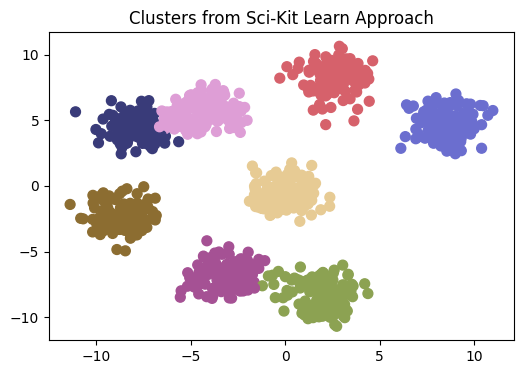

In [35]:
plt.figure(figsize=(6,4))
plt.title("Clusters from Sci-Kit Learn Approach")
plt.scatter(X[:, 0], X[:, 1], c = sklearn_clusters ,\
s=50, cmap='tab20b')
plt.show()

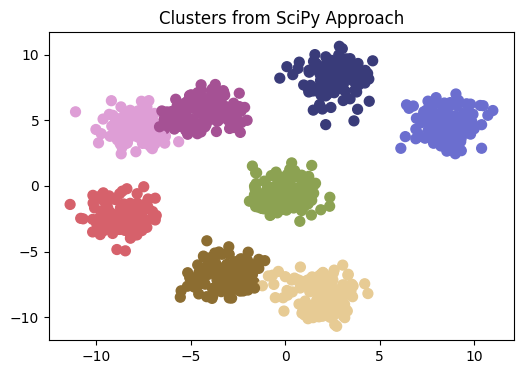

In [36]:
plt.figure(figsize=(6,4))
plt.title("Clusters from SciPy Approach")
plt.scatter(X[:, 0], X[:, 1], c = scipy_clusters ,\
s=50, cmap='tab20b')
plt.show()